# Preprocessing of the downloaded raw data
This notebook is designed to load the raw data, preprocess it and subsequently export it. Then the data can be used in the subsequent notebooks. The structure of this notebook is as follows:

0. Importing all required packages and functions
1. Neighborhood raw data: loading and explaining the data  
1.1. Neighborhood layer "labels" preprocessing  
1.2. Neighborhood layer "map" preprocessing  
1.3. Neighborhood layer "processing" preprocessing  
2. ZHWieNeu-Reports (raw data): loading, explaining and preprocessing
3. Further data: loading, explaining and preprocessing
4. Spatial join of the reports and neighborhood data

## 0. Import Block
Import all packages you need throughout this script.

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt

#to allow python to look at the correct location for the file
import sys
sys.path.append("../scripts")

from functions_zh_wie_neu import import_raw_data #type: ignore
from functions_zh_wie_neu import import_preprocessed_data #type: ignore
from functions_zh_wie_neu import export_processed_data #type: ignore

## 1. Neighborhood raw data
The neighborhood data consists of 3 layers. In the metadata the layers are introduced as follows (in german): 

#### 1 ADM_STATISTISCHE_QUARTIERE_B_P
Beschriftungspunkte der statistischen Quartiere. Dieser Punktlayer beinhaltet Informationen zur
optimalen Positionierung von Beschriftungen in Karten.

#### 2 ADM_STATISTISCHE_QUARTIERE_MAP
Dieser Layer kann für Datenvisualisierungen und kartographische Darstellungen verwendet werden.
Er enthält die vollständige Attributtabelle und ist generalisiert, sprich: die Geometrie wurde
vereinfacht und entspricht nicht der - aus Sicht der amtlichen Vermessung - korrekten Lage.

#### 3 ADM_STATISTISCHE_QUARTIERE_V
Dieser Layer enthält die exakten Grenzverläufe der Statistischen Quartiere und enthält die
vollständige Attributtabelle. Dieser Layer eignet sich zur Berechnung von Flächenangaben oder bei räumlichen Verschnitten. Als kartographischer Layer ist er jedoch nicht geeignet.
  
  
  
The full information can be found in the metadata. The metadata file is automatically downloaded with the raw data.

From this information, I selected the third layer for the spatial join with the Züriwieneu reports. For the subsequent visualisations, the other two layers will be useful, therefore they are prepared as well.

**Before starting the preprocessing, the data is loaded. Simultaneously, the crs and the active geometry of the data is verified:**

In [2]:
quartiere_labels=import_raw_data("quartiere.gpkg", layer="stzh.adm_statistische_quartiere_b_p") #neighborhood labels
quartiere_map=import_raw_data("quartiere.gpkg", layer="stzh.adm_statistische_quartiere_map") #cartographic map
quartiere_processing=import_raw_data("quartiere.gpkg", layer="stzh.adm_statistische_quartiere_v") #used for spatial join

The active geometry column of this geodataframe is called 'geometry'.
The active geometry column of this geodataframe is called 'geometry'.
The active geometry column of this geodataframe is called 'geometry'.


## 1.1. Quartiere_labels
This layer will only be used to add the labels to a cartographic map. Therefore, most attributes in the attribute table are not needed. The attribute table is given below: 

| Name      | Typ          | Beschreibung                                                                  |
|------------|---------------|--------------------------------------------------------------------------------|
| ORI        | DOUBLE        | Rotation der Beschriftung; undefiniert = 100.0                                |
| HALI       | LONG INTEGER  | Horizontaler Versatz zum Ursprungspunkt; undefiniert = Center                 |
| OBJECTID   | LONG INTEGER  | ESRI System-Identifikator. Nicht stabil über Zeit.                            |
| VALI       | LONG INTEGER  | Vertikaler Versatz zum Ursprungspunkt; undefiniert = Half                     |
| GEOMETRIE  | SHAPE         | Geometriefeld                                                                 |
| KUERZEL    | STRING        | -                                                                              |
| OBJID      | STRING        | System-Identifikator. Nicht stabil über Zeit.                                 |
| NAME       | STRING        | Bezeichnung des statistischen Quartiers                                       |


I keep only the name, kuerzel and geometry attributes. ORI, HALI and VALI could be useful as well, but as all attributes have the same values (ORI=0.0, HALI=1.0 and VALI=2.0), they can be dropped as well. 


In [3]:
quartiere_labels.info() #visually verify the nr of NaN, the active geometry and the column names

# only keep the selected columns
quartiere_labels=quartiere_labels[["name", "kuerzel", "geometry"]]

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   objid     34 non-null     str     
 1   objectid  34 non-null     int32   
 2   ori       34 non-null     float32 
 3   hali      34 non-null     float64 
 4   vali      34 non-null     float64 
 5   name      34 non-null     str     
 6   kuerzel   34 non-null     str     
 7   geometry  34 non-null     geometry
dtypes: float32(1), float64(2), geometry(1), int32(1), str(3)
memory usage: 2.4 KB


Lastly, we can export the preprocessed data into a GeoPackage file.

In [4]:
export_processed_data(quartiere_labels, "quartiere_labels.gpkg")

"The file 'quartiere_labels.gpkg' was exported to ..\\data\\processed\\quartiere_labels.gpkg."

## 1.2. Quartiere_map
This layer will only be used as the neighborhood-geometry in cartographic visualisations. The attribute table is given below:

| Name      | Typ          | Beschreibung                                                   |
|------------|---------------|-----------------------------------------------------------------|
| KNR        | DOUBLE        | Offizielle ID des Stadtkreises.                                |
| QNR        | DOUBLE        | Offizielle ID des Statistischen Quartiers.                     |
| OBJECTID   | LONG INTEGER  | Interner System-Identifikator. Nicht stabil über Zeit.         |
| GEOMETRIE  | SHAPE         | Geometriefeld.                                                 |
| KNAME      | STRING        | Name des Stadtkreises.                                         |
| OBJID      | STRING        | System-Identifikator. Nicht stabil über Zeit.                  |
| QNAME      | STRING        | Name des Statistischen Quartiers.                              |

From this attribute table, we can drop the OBJECTID and OBJID as they are not stable over time. The rest is not bad to keep.  



In [5]:
quartiere_map.info() # verify the column names. For example, the 'objid' column does not exist! 

#selecting the desired columns
quartiere_map=quartiere_map[["qnr", "qname", "knr", "kname", "geometry"]]

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   objectid  34 non-null     int32   
 1   qnr       34 non-null     int32   
 2   qname     34 non-null     str     
 3   knr       34 non-null     int32   
 4   kname     34 non-null     str     
 5   geometry  34 non-null     geometry
dtypes: geometry(1), int32(3), str(2)
memory usage: 1.9 KB


And the preprocessed data is then exported as a .gpkg file.

In [6]:
export_processed_data(quartiere_map, "quartiere_map.gpkg")

"The file 'quartiere_map.gpkg' was exported to ..\\data\\processed\\quartiere_map.gpkg."

## 1.3. Quartiere_processing
This is the layer that will be used for the spatial join with the reports of the ZüriWieNeu-Website. The attribute table looks as follows: 

| Name      | Typ          | Beschreibung                                                   |
|------------|---------------|-----------------------------------------------------------------|
| QNR        | DOUBLE        | Offizielle ID des Statistischen Quartiers.                     |
| KNR        | DOUBLE        | Offizielle ID des Stadtkreises.                                |
| OBJECTID   | LONG INTEGER  | Interner System-Identifikator. Nicht stabil über Zeit.         |
| GEOMETRIE  | SHAPE         | Geometriefeld.                                                 |
| KNAME      | STRING        | Name des Stadtkreises.                                         |
| OBJID      | STRING        | System-Identifikator. Nicht stabil über Zeit.                  |
| QNAME      | STRING        | Name des Statistischen Quartiers.                              |

So, the OBJID and OBJECTID are redundant and will be excluded for the future analysis

In [7]:
quartiere_processing.info()# verify the column names, NaN, and active geometry

#selecting the desired columns
quartiere_processing=quartiere_processing[["qnr", "qname", "knr", "kname", "geometry"]]

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   objid     34 non-null     str     
 1   objectid  34 non-null     int32   
 2   qname     34 non-null     str     
 3   qnr       34 non-null     int32   
 4   kname     34 non-null     str     
 5   knr       34 non-null     int32   
 6   geometry  34 non-null     geometry
dtypes: geometry(1), int32(3), str(3)
memory usage: 2.2 KB


For question 1, it would I aim to compare the absolute number of reports normalized by the area of each neighborhood! Therefore, I calculate the area of each neighborhood in km^2 and add it to the geodataframe.

In [8]:
# create a column containing each neighborhoods area in km^2
quartiere_processing["area_km2"]=(quartiere_processing.area/1000000)#the /1'000'000 is needed to get the area in km^2, as epsg=2056 is in metres

# check whether the result is approximately correct:
quartiere_processing["area_km2"].sum() #according to https://www.stadt-zuerich.ch/de/bildung/volksschule/unterrichtsmaterial/gang-dur-zueri/zuerich-in-zahlen.html, the area of the city of Zurich is 91.9 km^2

np.float64(91.87980054046378)

And now finally exporting the gdf after one last sneak peek to verify whether everything worked.

In [9]:
display(quartiere_processing.head(2))
export_processed_data(quartiere_processing, "quartiere_processed.gpkg")

,qnr,qname,knr,kname,geometry,area_km2
0,31,Alt-Wiedikon,3,Kreis 3,"POLYGON ((2680606.662 1247034.584, 2680626.356...",1.692468
1,74,Witikon,7,Kreis 7,"POLYGON ((2685858.632 1246502.629, 2685860.738...",4.933788


"The file 'quartiere_processed.gpkg' was exported to ..\\data\\processed\\quartiere_processed.gpkg."

### Note:
Until now, the number of non-null objects within each column was identical to the total number of rows. Therefore, no NaN-values are present in the data and we do not have to account for it here.

# 2. Reports of the Züri Wie Neu platform
This dataset contains all reports made by users online. The attribute table is given below:

| Name                  | Typ          | Beschreibung |
|-----------------------|---------------|---------------|
| AGENCY_SENT_DATETIME  | DATE          | Zeitpunkt der Benachrichtigung der verantwortlichen Stelle in der Stadtverwaltung [DD.MM.YYYY HH:MM:SS]. |
| REQUESTED_DATETIME    | DATE          | Datum und Zeitpunkt, an welchem die Meldung erstellt wurde [DD.MM.YYYY HH:MM:SS]. |
| UPDATED_DATETIME      | DATE          | Datum und Zeitpunkt, an welchem die Meldung zuletzt verändert wurde bzw. abgeschlossen wurde [DD.MM.YYYY HH:MM:SS]. |
| E                     | DOUBLE        | Ostkoordinate, CH1903+ / LV95. |
| N                     | DOUBLE        | Nordkoordinate, CH1903+ / LV95. |
| OBJECTID              | LONG INTEGER  | System-Identifikator. Nicht stabil über Zeit. |
| GEOMETRIE             | SHAPE         | Geometriefeld. |
| URL                   | STRING        | URL der Meldung auf „Züri wie neu“. |
| INTERFACE_USED        | STRING        | Verwendetes Interface [Web Interface, iPad, iPhone, Android]. |
| MEDIA_URL             | STRING        | URL zu den von der meldenden Person übermittelten Fotos. |
| DETAIL                | STRING        | Meldungsbeschreibung. |
| SERVICE_CODE          | STRING        | Kategorie [Abfall/Sammelstelle, Beleuchtung/Uhren, Graffiti, Signalisation/Lichtsignal, Grünflächen/Spielplätze, Strasse/Trottoir/Platz, Brunnen/Hydranten, VBZ/ÖV]. |
| SERVICE_NOTICE        | STRING        | Antwort der Stadtverwaltung. |
| SERVICE_REQUEST_ID    | STRING        | Eindeutige „Züri wie neu“-System-ID der Meldung. |
| STATUS                | STRING        | Bearbeitungsstatus [erfasst, aufgenommen, in Bearbeitung, beantwortet]. |
| TITLE                 | STRING        | Titel der Meldung. |
| DESCRIPTION           | STRING        | Kombination aus Titel und Meldungsbeschreibung. |
| SERVICE_NAME          | STRING        | Kategorie [Abfall/Sammelstelle, Beleuchtung/Uhren, Graffiti, Signalisation/Lichtsignal, Grünflächen/Spielplätze, Strasse/Trottoir/Platz, Brunnen/Hydranten, VBZ/ÖV]. |

After looking at the attribute table, I see that a lot of attributes are present, which are not important for my project. I will select the following attributes for further analysis: REQUESTED_DATETIME, E, N, GEOMETRIE, SERVICE_CODE, SERVICE REQUEST_ID and DESCRIPTION.

In [10]:
reports_gdf=import_raw_data("reports_ZHwieneu.gpkg") #no layers

#check for the column names
reports_gdf.info() #also here no NaNs

#selecting only the columns needed
reports_gdf=reports_gdf[["service_request_id", "requested_datetime", "e", "n", "geometry", "service_code", "description"]]

The active geometry column of this geodataframe is called 'geometry'.
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 73243 entries, 0 to 73242
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   objectid              73243 non-null  int32         
 1   service_request_id    73243 non-null  str           
 2   requested_datetime    73243 non-null  datetime64[ms]
 3   agency_sent_datetime  72411 non-null  datetime64[ms]
 4   updated_datetime      73243 non-null  datetime64[ms]
 5   e                     73243 non-null  int32         
 6   n                     73243 non-null  int32         
 7   service_code          73243 non-null  str           
 8   service_name          73243 non-null  str           
 9   status                73243 non-null  str           
 10  userid                73243 non-null  int32         
 11  title                 73243 non-null  str           
 

Now, I check whether it worked. Further, as we now have a unambiguous id for each report (the service_request_id column), I will see if I can set it as the new index.  

In [11]:
display(reports_gdf.head(3))

#checking whether every service_request_id is really unique
reports_gdf["service_request_id"].nunique() #--> it is, but as some numbers are missing, I will keep the automatic index (could be important in a for loop eventually) 


,service_request_id,requested_datetime,e,n,geometry,service_code,description
0,1,2013-03-14 15:16:15,2678968,1247548,POINT (2678968 1247548),Strasse/Trottoir/Platz,Auf dem Asp: Auf dem Asphalt des Bürgersteigs ...
1,2,2013-03-14 15:17:57,2680746,1249916,POINT (2680746 1249916),Strasse/Trottoir/Platz,Vermessungs: Vermessungspunkt ist nicht mehr b...
2,4,2013-03-15 09:14:16,2684605,1251431,POINT (2684605 1251431),Strasse/Trottoir/Platz,Beim Trotto: Beim Trottoir sind einige Randste...


73243

finally export the processed report-data

In [12]:
export_processed_data(reports_gdf, "reports_processed.gpkg")

"The file 'reports_processed.gpkg' was exported to ..\\data\\processed\\reports_processed.gpkg."

## 3. Preprocessing of additional data
In this section the additional data is preprocessed.
#### 3.1 Public Transport Lines
This dataset is used to underline the results of Q3 (How do the reports of the category VBZ/ÖV cluster?). The dataset contains 3 layers. I selected the first (108.1 - S-Bahn-Linien des ZVV) and third layer (108.3 - Zusammengefasste Bahn- und Buslinien des ZVV). The first layer contains the railway lines, the third the bus and tram lines.

First, I focus on the railway lines. The data has to be loaded and the spatial extent has to be reduced to the area of the city of zurich. For that, I will use the overlay function. For the overlay, the quartiere_map.gpkg is used again.

In [13]:
#importing the layers
railway_lines=import_raw_data("public_transport_lines.gpkg", layer="zvv_s_bahn_linien_l")
quartiere_map=import_preprocessed_data("quartiere_map.gpkg") 

#perform the overlay
railway_lines_city=gpd.overlay(railway_lines, quartiere_map, how="intersection") #intersection also takes the railway lines on the border into the new gdf

The active geometry column of this geodataframe is called 'geometry'.
The active geometry column of this geodataframe is called 'geometry'.


Subsequently, the tram and bus lines are loaded and overlayed. As the vbz is responsible for the operation of these lines, the layer is called vbz_lines. For the overlayed layer, the ending _city is added: vbz_lines_city.

In [14]:
#importing the bus and tram lines
vbz_lines=import_raw_data("public_transport_lines.gpkg", layer="zvv_linien_gen_l") #third layer

#perform the overlay
vbz_lines_city=gpd.overlay(vbz_lines, quartiere_map, how="intersection")

The active geometry column of this geodataframe is called 'geometry'.


Visually confirm whether both overlays worked. Just a quick plot, no cartographic masterpiece

<Axes: >

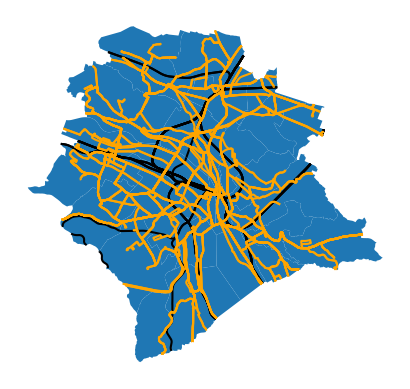

In [15]:
fig, ax = plt.subplots()
ax.axis("off")

#added layers
quartiere_map.plot(ax=ax, zorder=0)
railway_lines_city.plot(ax=ax, color="black", zorder=1)
vbz_lines_city.plot(ax=ax, color="orange", zorder=2)

As everything appears to be alright with the overlay, the newly created geometries are exported:

In [16]:
export_processed_data(railway_lines_city, "railway_lines.gpkg")
export_processed_data(vbz_lines_city, "vbz_lines.gpkg")

"The file 'vbz_lines.gpkg' was exported to ..\\data\\processed\\vbz_lines.gpkg."

## 4. Spatial join

The last prerequisite for then subsequently investigating the 5 questions selected is to combine the two datasets. For this a spatial join is used.

* We will use the spatial predicate "within" to avoid potential duplicates on the borders. But, this method requires us to manually check whether a point is not assigned to a neighborhood at all. 
* Further, the attributes of the neighborhood gdf should be attached to the reports gdf. Therefore, the join type left (with reports as the left input) was selected. 
* Also the area_km^2 attribute will be spatially joined. As putting the area of a neighborhood next to a point geometry, the area is removed immediately after the join. 

In [17]:
# reload the processed files again
quartiere_processed=import_preprocessed_data("quartiere_processed.gpkg")
reports_processed=import_preprocessed_data("reports_processed.gpkg")

#then do the spatial join...
reports_and_quartiere=gpd.sjoin(reports_processed, quartiere_processed, how="left", predicate="within")

#...drop the area_column as it is not meaningful in the newly created dataset...
reports_and_quartiere=reports_and_quartiere.drop(columns=["area_km2"])

#... and verify whether it worked.
reports_and_quartiere.head(2)

The active geometry column of this geodataframe is called 'geometry'.
The active geometry column of this geodataframe is called 'geometry'.


,service_request_id,requested_datetime,e,n,service_code,description,geometry,index_right,qnr,qname,knr,kname
0,1,2013-03-14 15:16:15,2678968,1247548,Strasse/Trottoir/Platz,Auf dem Asp: Auf dem Asphalt des Bürgersteigs ...,POINT (2678968 1247548),16,91,Albisrieden,9,Kreis 9
1,2,2013-03-14 15:17:57,2680746,1249916,Strasse/Trottoir/Platz,Vermessungs: Vermessungspunkt ist nicht mehr b...,POINT (2680746 1249916),20,101,Höngg,10,Kreis 10


Quickly compare whether the number of rows is the same before and after the join: 

In [18]:
if reports_and_quartiere.shape[0]==reports_processed.shape[0]: #rows before and after the join should match
    print("You have the same number of rows before and after the spatial join.")
else:
    print(f"You lost {reports_and_quartiere.shape[0]-reports_processed.shape[0]} rows during your spatial join. They could be exactly on the border of two neighborhoods or outside the city of Zurich.")

You have the same number of rows before and after the spatial join.


Quickly check for resulting NaN values in the 'qnr' column

In [19]:
reports_and_quartiere["qnr"].isna().sum() #also no NaN --> all points were assigned to neighborhood 

np.int64(0)

Last but not least, the spatially joined dataset has to be exported:

In [20]:
export_processed_data(reports_and_quartiere, "reports_quartiere_sjoin.gpkg")

"The file 'reports_quartiere_sjoin.gpkg' was exported to ..\\data\\processed\\reports_quartiere_sjoin.gpkg."

# How to continue?
The data are now finally processed and ready to be used in the subsequent spatial questions Q1-Q4. These questions are addressed in individual notebooks.